In [3]:
import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer

In [4]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result

In [5]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (a[0]-c[0])*(b[1]-c[1]) - (b[0]-c[0]) * (a[1]-c[1])

In [6]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [7]:
def det(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return a[0]*b[1]+b[0]*c[1] +c[0]*a[1] - b[1]*c[0]-c[1]*a[0]-a[1]*b[0]

In [8]:
EPS = 10 **(-24)
def orient(a,b,c):
    r = mat_det_2x2(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1

In [9]:

def Andrew(Q):
    if len(Q)<=1: 
        return Q
    #sortuje po x jeśli jest remis to po y
    # print(Q)
    Q.sort(key = lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    #kolejność wyznacznia łańcuchów zapewnia 
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i])==1):
            L.pop()
        L.append(Q[i])
    for i in range(n-1, -1,-1):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i])==1):
            U.pop()
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull  = L + U
    return convex_hull

In [10]:

Test().runtest(1, Andrew)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 0.680s


In [15]:
def Andrew_vis(Q):
    v = Visualizer()
    blue = "#1f77b4"
    v.add_point(Q, color = blue)
    #sortuje po x jeśli jest remis to po y
    Q.sort(key = lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    edges = []
    #kolejność wyznacznia łańcuchów zapewnia 
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        v.add_point(Q[i], color="green")
        if len(L)>0:
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i])==1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = L.pop()
            v.add_point(x, color=blue)
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        L.append(Q[i])
    edges = []
    for i in range(n-1, -1,-1):
        v.add_point(Q[i], color="red")
        if len(U)>0:
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i])==1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = U.pop()
            if x not in L:
                v.add_point(x, color=blue)
            else:
                v.add_point(x, color="green")
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull  = L + U
    return convex_hull, v

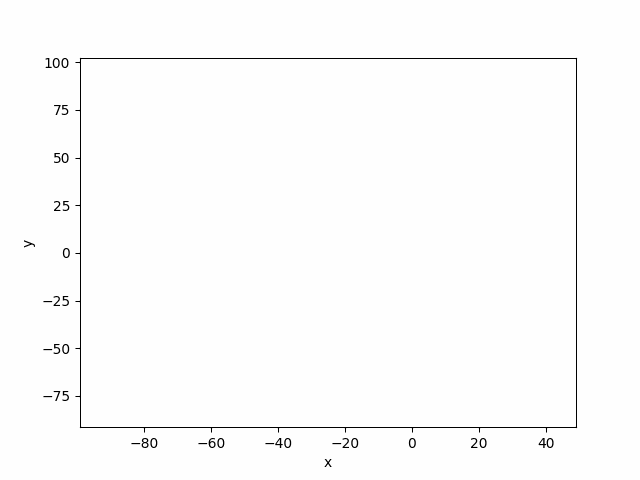

In [17]:
x = generate_uniform_points(-100, 100, 10)
hull, v = Andrew_vis(x)
v.show_gif()